In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np

from functools import lru_cache, partial
from tabulate import tabulate

import torch
import torch.nn.functional as F
from torch.nn.attention.flex_attention import (
    _DEFAULT_SPARSE_BLOCK_SIZE,
    BlockMask,
    create_block_mask,
    create_mask,
    flex_attention,
)
from triton.testing import do_bench

In [2]:
def create_cross_scale_attn_mask(
    scale_schedule=None,
    kernel_schedule=None,
    q_scale_idx: int = 12,
    attn_sink_scale: int = 5,
    device: str = "cuda",
    is_last_scale: bool = True,
):
    """
    一个统一的稀疏 attention mask mod，用于为HART模型的完整注意力矩阵
    （例如 4096x9750）进行局部稀疏化。

    该函数能够根据 Key/Value 的一维索引 kv_idx，自动推断其所属的历史尺度、
    该尺度的网格尺寸，以及在该尺度内的局部坐标，然后应用局部注意力逻辑。
    """
    H_q, W_q = scale_schedule[q_scale_idx]

    relevant_schedule = scale_schedule[:q_scale_idx + 1]
    relevant_kernel_schedule = kernel_schedule[:q_scale_idx + 1]

    kv_tokens_per_scale = [h * w for h, w in relevant_schedule]
    kv_tokens_per_scale[0] = 300
    print(f'{kv_tokens_per_scale=}')

    kv_cumulative_tokens = np.cumsum(kv_tokens_per_scale)
    print(f'{kv_cumulative_tokens=}')

    kv_slice_indices = np.insert(kv_cumulative_tokens, 0, 0)
    print(f'{kv_slice_indices=}')

    # Calculate the token boundary for the dense attention sink
    attn_sink_boundary = int(kv_slice_indices[attn_sink_scale]) if attn_sink_scale > 0 else 0
    print(f'{attn_sink_boundary=}')

    scale_schedule_tensor = torch.tensor(relevant_schedule, device=device, dtype=torch.int)
    kv_slice_indices_tensor = torch.tensor(kv_slice_indices, device=device, dtype=torch.int)
    kernel_schedule_tensor = torch.tensor(relevant_kernel_schedule, device=device, dtype=torch.int)

    def gen_mask_mod(b, h, q_idx, kv_idx):

        # Condition 1: Is the Key/Value token in the dense "attention sink" region?
        # If so, it's always attended to.
        attn_sink_mask = (kv_idx < attn_sink_boundary)

        # --- The rest of the logic is for the sparse region ---
        # 1. 计算 Query 的 2D 坐标 (这部分不变)
        q_y, q_x = q_idx // W_q, q_idx % W_q
        
        # 2. 核心逻辑: 确定每个 kv_idx 属于哪个历史尺度
        #    torch.searchsorted 是一个高效的查找操作，它会返回每个 kv_idx
        #    应该插入到 slice_indices 中的哪个位置，从而确定其所属的尺度。
        #    我们减去1来获得正确的0-based尺度索引。
        scale_index_k = torch.searchsorted(kv_slice_indices_tensor, kv_idx, right=True) - 1
        
        # 3. 根据尺度索引，获取该尺度的网格尺寸 (H_k, W_k)
        #    使用 torch.gather 来避免在 vmap 环境中的索引问题
        H_k_tensor = torch.gather(scale_schedule_tensor[:, 0], 0, scale_index_k)
        W_k_tensor = torch.gather(scale_schedule_tensor[:, 1], 0, scale_index_k)
        
        # 4. 计算 kv_idx 在其自身尺度内的局部一维索引
        start_indices_k = torch.gather(kv_slice_indices_tensor, 0, scale_index_k)
        kernel_size_k = torch.gather(kernel_schedule_tensor, 0, scale_index_k)
        relative_kv_idx = kv_idx - start_indices_k
        
        # 5. 计算 Key/Value 的 2D 坐标 Calculate Key/Value's 2D coordinates
        kv_y, kv_x = relative_kv_idx // W_k_tensor, relative_kv_idx % W_k_tensor
        
        # 6. 坐标重缩放，找到 Query 在 Key 网格中的对应中心点 Rescale coordinates
        center_y = torch.round((q_y.float() / H_q) * H_k_tensor)
        center_x = torch.round((q_x.float() / W_q) * W_k_tensor)
        
        # 7. 判断 Key/Value token 是否在中心点 KERNEL_SIZE//2 的邻域内
            # Check neighborhood using the per-scale kernel size
        half_kernel = kernel_size_k // 2
        vertical_mask = (center_y - kv_y).abs() <= half_kernel
        horizontal_mask = (center_x - kv_x).abs() <= half_kernel
        is_in_sparse_region = vertical_mask & horizontal_mask
        
        # return vertical_mask & horizontal_mask
        # A token is attended to if it's in the dense region OR in the local sparse region.
        return attn_sink_mask | is_in_sparse_region
    
    return gen_mask_mod



In [3]:
def create_cross_scale_block_attn_mask(
    scale_schedule=None,
    kernel_schedule=None,
    q_scale_idx: int = 12,
    attn_sink_scale: int = 5,
    device: str = "cuda",
    block_size: int = 128, # Added block_size as a parameter
):
    """
    Generates a highly efficient, purely block-sparse mask for Infinity's attention.

    This function follows a two-step process:
    1. It first generates the fine-grained, hybrid sparse-dense attention mask internally.
    2. It then converts this fine-grained mask into a purely block-sparse mask by
       promoting any non-empty block to a fully dense block.
    3. Finally, it returns a new, very simple mask_mod function that performs a
       fast lookup on the pre-computed block-level mask.
    """
    # --- Step 0: Parameter Setup (same as before) ---
    H_q, W_q = scale_schedule[q_scale_idx]
    S_q = H_q * W_q

    relevant_schedule = scale_schedule[:q_scale_idx + 1]
    relevant_kernel_schedule = kernel_schedule[:q_scale_idx + 1]
    kv_tokens_per_scale = [h * w for h, w in relevant_schedule]
    kv_tokens_per_scale[0] = 300
    kv_cumulative_tokens = np.cumsum(kv_tokens_per_scale)
    kv_slice_indices = np.insert(kv_cumulative_tokens, 0, 0)
    S_k = kv_cumulative_tokens[-1]
    attn_sink_boundary = int(kv_slice_indices[attn_sink_scale]) if attn_sink_scale > 0 else 0

    scale_schedule_tensor = torch.tensor(relevant_schedule, device=device, dtype=torch.int)
    kv_slice_indices_tensor = torch.tensor(kv_slice_indices, device=device, dtype=torch.int)
    kernel_schedule_tensor = torch.tensor(relevant_kernel_schedule, device=device, dtype=torch.int)

    # --- Step 1: Generate the Fine-Grained Mask Internally ---
    
    # This is the original fine-grained mask generation logic, now nested
    def gen_fine_grained_mask_mod(b, h, q_idx, kv_idx):
        attn_sink_mask = (kv_idx < attn_sink_boundary)
        scale_index_k = torch.searchsorted(kv_slice_indices_tensor, kv_idx, right=True) - 1
        H_k_tensor = torch.gather(scale_schedule_tensor[:, 0], 0, scale_index_k)
        W_k_tensor = torch.gather(scale_schedule_tensor[:, 1], 0, scale_index_k)
        start_indices_k = torch.gather(kv_slice_indices_tensor, 0, scale_index_k)
        kernel_size_k = torch.gather(kernel_schedule_tensor, 0, scale_index_k)
        relative_kv_idx = kv_idx - start_indices_k
        kv_y, kv_x = relative_kv_idx // W_k_tensor, relative_kv_idx % W_k_tensor
        center_y = torch.round(( (q_idx // W_q).float() / H_q) * H_k_tensor)
        center_x = torch.round(( (q_idx % W_q).float() / W_q) * W_k_tensor)
        half_kernel = kernel_size_k // 2
        is_in_sparse_region = ((center_y - kv_y).abs() <= half_kernel) & ((center_x - kv_x).abs() <= half_kernel)
        return attn_sink_mask | is_in_sparse_region

    print("Step 1: Generating internal fine-grained mask...")
    fine_grained_mask = create_mask(gen_fine_grained_mask_mod, 1, 1, S_q, S_k, device=device).squeeze()

    # --- Step 2: Convert to a Pure Block-Sparse Mask ---
    print(f"Step 2: Converting to {block_size}x{block_size} block-sparse format...")
    
    # Pad the fine-grained mask to be divisible by block_size
    pad_q = (block_size - S_q % block_size) % block_size
    pad_k = (block_size - S_k % block_size) % block_size
    padded_mask = F.pad(fine_grained_mask, (0, pad_k, 0, pad_q), "constant", False)
    
    padded_S_q, padded_S_k = padded_mask.shape
    num_q_blocks = padded_S_q // block_size
    num_k_blocks = padded_S_k // block_size

    # Reshape, permute, and reduce to get the block-level mask
    # The logic is: if ANY value in a block is True, the whole block becomes True.
    block_level_mask = padded_mask.reshape(num_q_blocks, block_size, num_k_blocks, block_size) \
                                  .permute(0, 2, 1, 3) \
                                  .any(dim=(-1, -2))

    # --- Step 3: Return a Simple Lookup Function ---
    print("Step 3: Returning simplified block-lookup mask function.")
    
    # This closure captures the pre-computed block_level_mask
    def final_block_mask_mod(b, h, q_idx, kv_idx):
        q_block_idx = q_idx // block_size
        k_block_idx = kv_idx // block_size
        # This is now a simple, fast lookup
        return block_level_mask[q_block_idx, k_block_idx]
    
    return final_block_mask_mod

In [4]:
@lru_cache
def create_block_mask_cached(score_mod, B, H, M, N, device="cuda", block_size: int = _DEFAULT_SPARSE_BLOCK_SIZE):
    block_mask = create_block_mask(score_mod, B, H, M, N, device=device, BLOCK_SIZE=block_size)
    return block_mask


def calculate_tflops(flops: float, time_ms: float, multiplier: int) -> float:
    return multiplier * flops * (1e3 / time_ms) / 1e12


def test_mask2(     # support S_q != S_kv
    score_mod=None,
    mask_mod=None,
    B=2,
    H=16,
    S_q=4096,
    S_kv=10521,
    D=128,
    skip_correctness=False,
    print_mask=True,
    sparse_block_size: int = _DEFAULT_SPARSE_BLOCK_SIZE,
):
    assert (
        score_mod is not None or mask_mod is not None
    ), "Must provide a score_mod or mask_mod"
    query = torch.randn(
        B, H, S_q, D, device="cuda", dtype=torch.float16, requires_grad=True
    )
    key = torch.randn(
        B, H, S_kv, D, device="cuda", dtype=torch.float16, requires_grad=True
    )
    value = torch.randn(
        B, H, S_kv, D, device="cuda", dtype=torch.float16, requires_grad=True
    )
    gradOut = torch.randn(B, H, S_q, D, device="cuda", dtype=torch.float16)

    if mask_mod is not None:
        print(f"Using sparse block size: {sparse_block_size}")
        block_mask = create_block_mask_cached(mask_mod, 1, 1, S_q, S_kv, device=query.device, block_size=sparse_block_size)
    else:
        block_mask = None
    sdpa_mask_fn = mask_mod if mask_mod is not None else score_mod
    mask = create_mask(sdpa_mask_fn, 1, 1, S_q, S_kv, device=query.device)

    fa2 = lambda: F.scaled_dot_product_attention(
        query, key, value,
    )
    xformers_mask = lambda: F.scaled_dot_product_attention(
        query, key, value, attn_mask=mask
    )
    flex_attention_call = lambda: flex_attention(
        query, key, value, score_mod=score_mod, block_mask=block_mask
    )

    results = []
    if block_mask is not None:
        density = (100 - block_mask.sparsity()) / 100
    else:
        density = 1.0
    fav2_flops = B * H * D * S_q * S_kv
    flops = density * B * H * D * S_q * S_kv

    # Forward pass
    fa2_time = do_bench(fa2)
    xformers_mask_time = do_bench(xformers_mask)
    flex_ms = do_bench(flex_attention_call)

    # Backward pass
    fa2_out = fa2()
    xformers_out = xformers_mask()
    flex_out = flex_attention_call()

    fa2_bw_time = do_bench(
        lambda: fa2_out.backward(gradOut, retain_graph=True)
    )
    xformers_mask_bw_time = do_bench(
        lambda: xformers_out.backward(gradOut, retain_graph=True)
    )
    flex_bw_ms = do_bench(lambda: flex_out.backward(gradOut, retain_graph=True))

    # Inline correctness check
    if not skip_correctness:
        xformers_outs = []
        flex_outs = []

        query.grad = None
        key.grad = None
        value.grad = None

        out1 = xformers_mask()
        xformers_outs.append(out1)
        out1.backward(gradOut)
        xformers_outs += [query.grad, key.grad, value.grad]

        query.grad = None
        key.grad = None
        value.grad = None

        out2 = flex_attention_call()
        flex_outs.append(out2)
        out2.backward(gradOut)
        flex_outs += [query.grad, key.grad, value.grad]
        for flex, xformer in zip(flex_outs, xformers_outs):
            torch.testing.assert_close(flex, xformer, atol=1e-1, rtol=1e-2)

        print("Correctness check passed ✅")
    # Usage in your results formatting:
    results = [
        [
            "FA2",
            f"{fa2_time:.4f}",
            f"{calculate_tflops(fav2_flops, fa2_time, 4):.2f}",
            f"{fa2_bw_time:.4f}",
            f"{calculate_tflops(fav2_flops, fa2_bw_time, 10):.2f}",
        ],
        [
            "F.sdpa + mask",
            f"{xformers_mask_time:.4f}",
            f"{calculate_tflops(flops, xformers_mask_time, 4):.2f}",
            f"{xformers_mask_bw_time:.4f}",
            f"{calculate_tflops(flops, xformers_mask_bw_time, 10):.2f}",
        ],
        [
            "flexattention",
            f"{flex_ms:.4f}",
            f"{calculate_tflops(flops, flex_ms, 4):.2f}",
            f"{flex_bw_ms:.4f}",
            f"{calculate_tflops(flops, flex_bw_ms, 10):.2f}",
        ],
    ]
    print(
        f"\nResults for {score_mod.__name__ if score_mod is not None else mask_mod.__name__}:"
    )
    print(
        tabulate(
            results,
            headers=[
                "Operation",
                "FW Time (ms)",
                "FW FLOPS (TF/s)",
                "BW Time (ms)",
                "BW FLOPS (TF/s)",
            ],
            tablefmt="grid",
        )
    )
    if print_mask:
        print(f"\nBlock Mask:\n{block_mask}")
        print(f"\nFull Block Mask:\n{block_mask.to_string(grid_size=-1)}")

    # Clean up to save memory
    del query, key, value, gradOut, fa2_out, xformers_out, flex_out
    torch.cuda.empty_cache()

In [5]:
def visualize_mask(
    mask_fun, 
    scale_schedule,
    q_scale_idx: int = 12,
    block_size: int = 128,
    filename: str = "mask_viz.png",
    title: str = "Attention Mask Visualization",
):
    """
    为指定Query尺度的完整注意力矩阵生成、可视化并保存稀疏mask。

    Args:
        query_scale_index (int): 当前Query是第几个尺度 (1-based, e.g., 13)。
        full_scale_schedule (list): 包含所有尺度 (h, w) 的完整列表。
        KERNEL_SIZE (int): 局部注意力窗口大小。
        filename (str): 保存图像的文件名。
    """
    device = "cuda" if torch.cuda.is_available() else "cpu"

    H_q, W_q = scale_schedule[q_scale_idx]
    S_q = H_q * W_q

    relevant_schedule = scale_schedule[:q_scale_idx + 1]
    tokens_per_scale = [h * w for h, w in relevant_schedule]
    tokens_per_scale[0] = 300
    kv_slice_indices = np.insert(np.cumsum(tokens_per_scale), 0, 0)
    S_k = kv_slice_indices[-1]
    scale_boundaries_k = kv_slice_indices.tolist()
    
    mask_tensor = create_mask(mask_fun, 1, 1, S_q, S_k, device=device)
    mask_for_viz = mask_tensor.squeeze().cpu().numpy()
    
    print("Mask generated. Now creating and saving visualization...")

    # --- 可视化并保存 ---
    dpi = 150
    # 调整图像大小以更好地适应长条形的mask
    fig_width = max(15, S_k / dpi) 
    fig_height = S_q / S_k * fig_width # 保持长宽比

    fig, ax = plt.subplots(figsize=(fig_width, fig_height), dpi=dpi)
    ax.imshow(mask_for_viz, cmap='gray', interpolation='nearest', aspect='auto')

    # --- Feature 1: Draw Block Grid (Light Red Dashed Lines) ---
    # Horizontal lines for Query blocks
    for y in range(block_size, S_q, block_size):
        ax.axhline(y - 0.5, color='red', linestyle='--', linewidth=0.5, alpha=0.7)
    # Vertical lines for Key/Value blocks
    for x in range(block_size, S_k, block_size):
        ax.axvline(x - 0.5, color='red', linestyle='--', linewidth=0.5, alpha=0.7)

    # --- Feature 2: Draw Scale Boundaries (Yellow Dashed Lines) ---
    # We only draw vertical lines on the KV (x) axis.
    # We skip the first boundary (at 0) and the last (at S_k).
    for boundary in scale_boundaries_k[1:-1]:
         ax.axvline(x=boundary - 0.5, color='yellow', linestyle='--', linewidth=1.2)

    # Set plot limits to be tight around the mask
    ax.set_xlim(-0.5, S_k - 0.5)
    ax.set_ylim(S_q - 0.5, -0.5)
    
    ax.set_title(title, fontsize=16)
    ax.set_ylabel(f"Query Token Index (S_q = {S_q})", fontsize=12)
    ax.set_xlabel(f"Key/Value Token Index (S_k = {S_k})", fontsize=12)
    
    save_dir = os.path.join(os.getcwd(), 'attn_map_vis')
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, filename)

    plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    
    print(f"✅ Visualization with grid overlays saved to: {save_path}\n")

In [6]:
# ------ Setup ------
torch.set_default_device("cuda")
torch.manual_seed(0)

torch._dynamo.config.cache_size_limit = 1000

# Compile the flex_attention function
# flex_attention = torch.compile(flex_attention, dynamic=False)

# For better performance, you can use:
flex_attention = torch.compile(flex_attention, dynamic=False, mode="max-autotune-no-cudagraphs")

data_type = torch.float16

In [7]:
text_token_len = 300

scale_schedule = [
    (0, 0),     # 300 text token len
    (2, 2), (3, 3), (4, 4), (5, 5), (7, 7), (9, 9), (12, 12),
    (16, 16), (21, 21), (27, 27), (36, 36), (48, 48), (64, 64)
]

kernel_schedule = [
    -1, -1, -1, -1, -1,      # attn sink: scale 0(300), 1(2x2=4), 2(3x3=9), 3(4x4=16), 4(5x5=25) --> total len = 354
    -1,      # scale 5 (7x7)
    # --- attn sink ---
    -1,      # scale 6 (9x9)
    -1,      # scale 7 (12x12)
    1,      # scale 8 (16x16)
    1,      # scale 9 (21x21)
    1,      # scale 10 (27x72)
    1,      # scale 11 (36x36)
    3,       # scale 12 (48x48)
    5,      # scale 13 (64x64)
]

In [8]:
q_scale_idx = 13
attn_sink_scale = 6

S_q = scale_schedule[q_scale_idx][0] * scale_schedule[q_scale_idx][1]
S_kv = sum([h * w for h, w in scale_schedule[:q_scale_idx + 1]])
S_kv += text_token_len
block_size = 64
batch, num_heads, head_dim = 2, 24, 64


S_q, S_kv

(4096, 9750)

In [9]:
hart_mask_mod = create_cross_scale_attn_mask(
    scale_schedule=scale_schedule,
    kernel_schedule=kernel_schedule,
    q_scale_idx=q_scale_idx,    # 当前Query是第几个尺度 (0-based, e.g., 12)
    attn_sink_scale=attn_sink_scale, # 注意力汇聚的尺度 (0-based, e.g., 5)
    device="cuda",
)

kv_tokens_per_scale=[300, 4, 9, 16, 25, 49, 81, 144, 256, 441, 729, 1296, 2304, 4096]
kv_cumulative_tokens=array([ 300,  304,  313,  329,  354,  403,  484,  628,  884, 1325, 2054,
       3350, 5654, 9750])
kv_slice_indices=array([   0,  300,  304,  313,  329,  354,  403,  484,  628,  884, 1325,
       2054, 3350, 5654, 9750])
attn_sink_boundary=403


In [10]:
test_mask2(
    mask_mod=hart_mask_mod,
    B=batch, H=num_heads, D=head_dim,
    S_q=S_q, S_kv=S_kv, 
    sparse_block_size=block_size
)

Using sparse block size: 64


AUTOTUNE flex_attention_backward(2x24x4096x64, 2x24x9750x64, 2x24x9750x64, 2x24x4096, 2x24x4096, 2x24x4096x64, 2x24x4096x64, 2x24x9750x64, 1x1x64, 1x1x64x153, 1x1x153, 1x1x153x64, 1x1x64, 1x1x64x153, 1x1x153, 1x1x153x64, 15, 14x2, 14)
  triton_flex_attention_backward_11 17.6108 ms 100.0% BLOCKS_ARE_CONTIGUOUS=False, BLOCK_M1=64, BLOCK_M2=64, BLOCK_N1=64, BLOCK_N2=64, FLOAT32_PRECISION="'tf32'", GQA_SHARED_HEADS=1, HAS_FULL_BLOCKS=True, IS_DIVISIBLE=False, OUTPUT_LOGSUMEXP=True, PRESCALE_QK=False, QK_HEAD_DIM=64, QK_HEAD_DIM_ROUNDED=64, ROWS_GUARANTEED_SAFE=False, SAFE_HEAD_DIM=True, SM_SCALE=0.125, SPARSE_KV_BLOCK_SIZE=64, SPARSE_Q_BLOCK_SIZE=64, V_HEAD_DIM=64, V_HEAD_DIM_ROUNDED=64, WRITE_DQ=True, num_stages=3, num_warps=4
  triton_flex_attention_backward_1 17.6334 ms 99.9% BLOCKS_ARE_CONTIGUOUS=False, BLOCK_M1=64, BLOCK_M2=64, BLOCK_N1=64, BLOCK_N2=64, FLOAT32_PRECISION="'tf32'", GQA_SHARED_HEADS=1, HAS_FULL_BLOCKS=True, IS_DIVISIBLE=False, OUTPUT_LOGSUMEXP=True, PRESCALE_QK=False, Q

Correctness check passed ✅

Results for gen_mask_mod:
+---------------+----------------+-------------------+----------------+-------------------+
| Operation     |   FW Time (ms) |   FW FLOPS (TF/s) |   BW Time (ms) |   BW FLOPS (TF/s) |
+===============+================+===================+================+===================+
| FA2           |         1.6355 |            300.06 |         4.9658 |            247.06 |
+---------------+----------------+-------------------+----------------+-------------------+
| F.sdpa + mask |         5.8607 |             11.9  |        14.3314 |             12.17 |
+---------------+----------------+-------------------+----------------+-------------------+
| flexattention |         0.6785 |            102.81 |         2.3016 |             75.77 |
+---------------+----------------+-------------------+----------------+-------------------+

Block Mask:
BlockMask(shape=(1, 1, 4096, 9750), sparsity=85.78%, 
(0, 0)
░░░░░░  ░░  ░░        ░░                
░░░

Mask generated. Now creating and saving visualization...


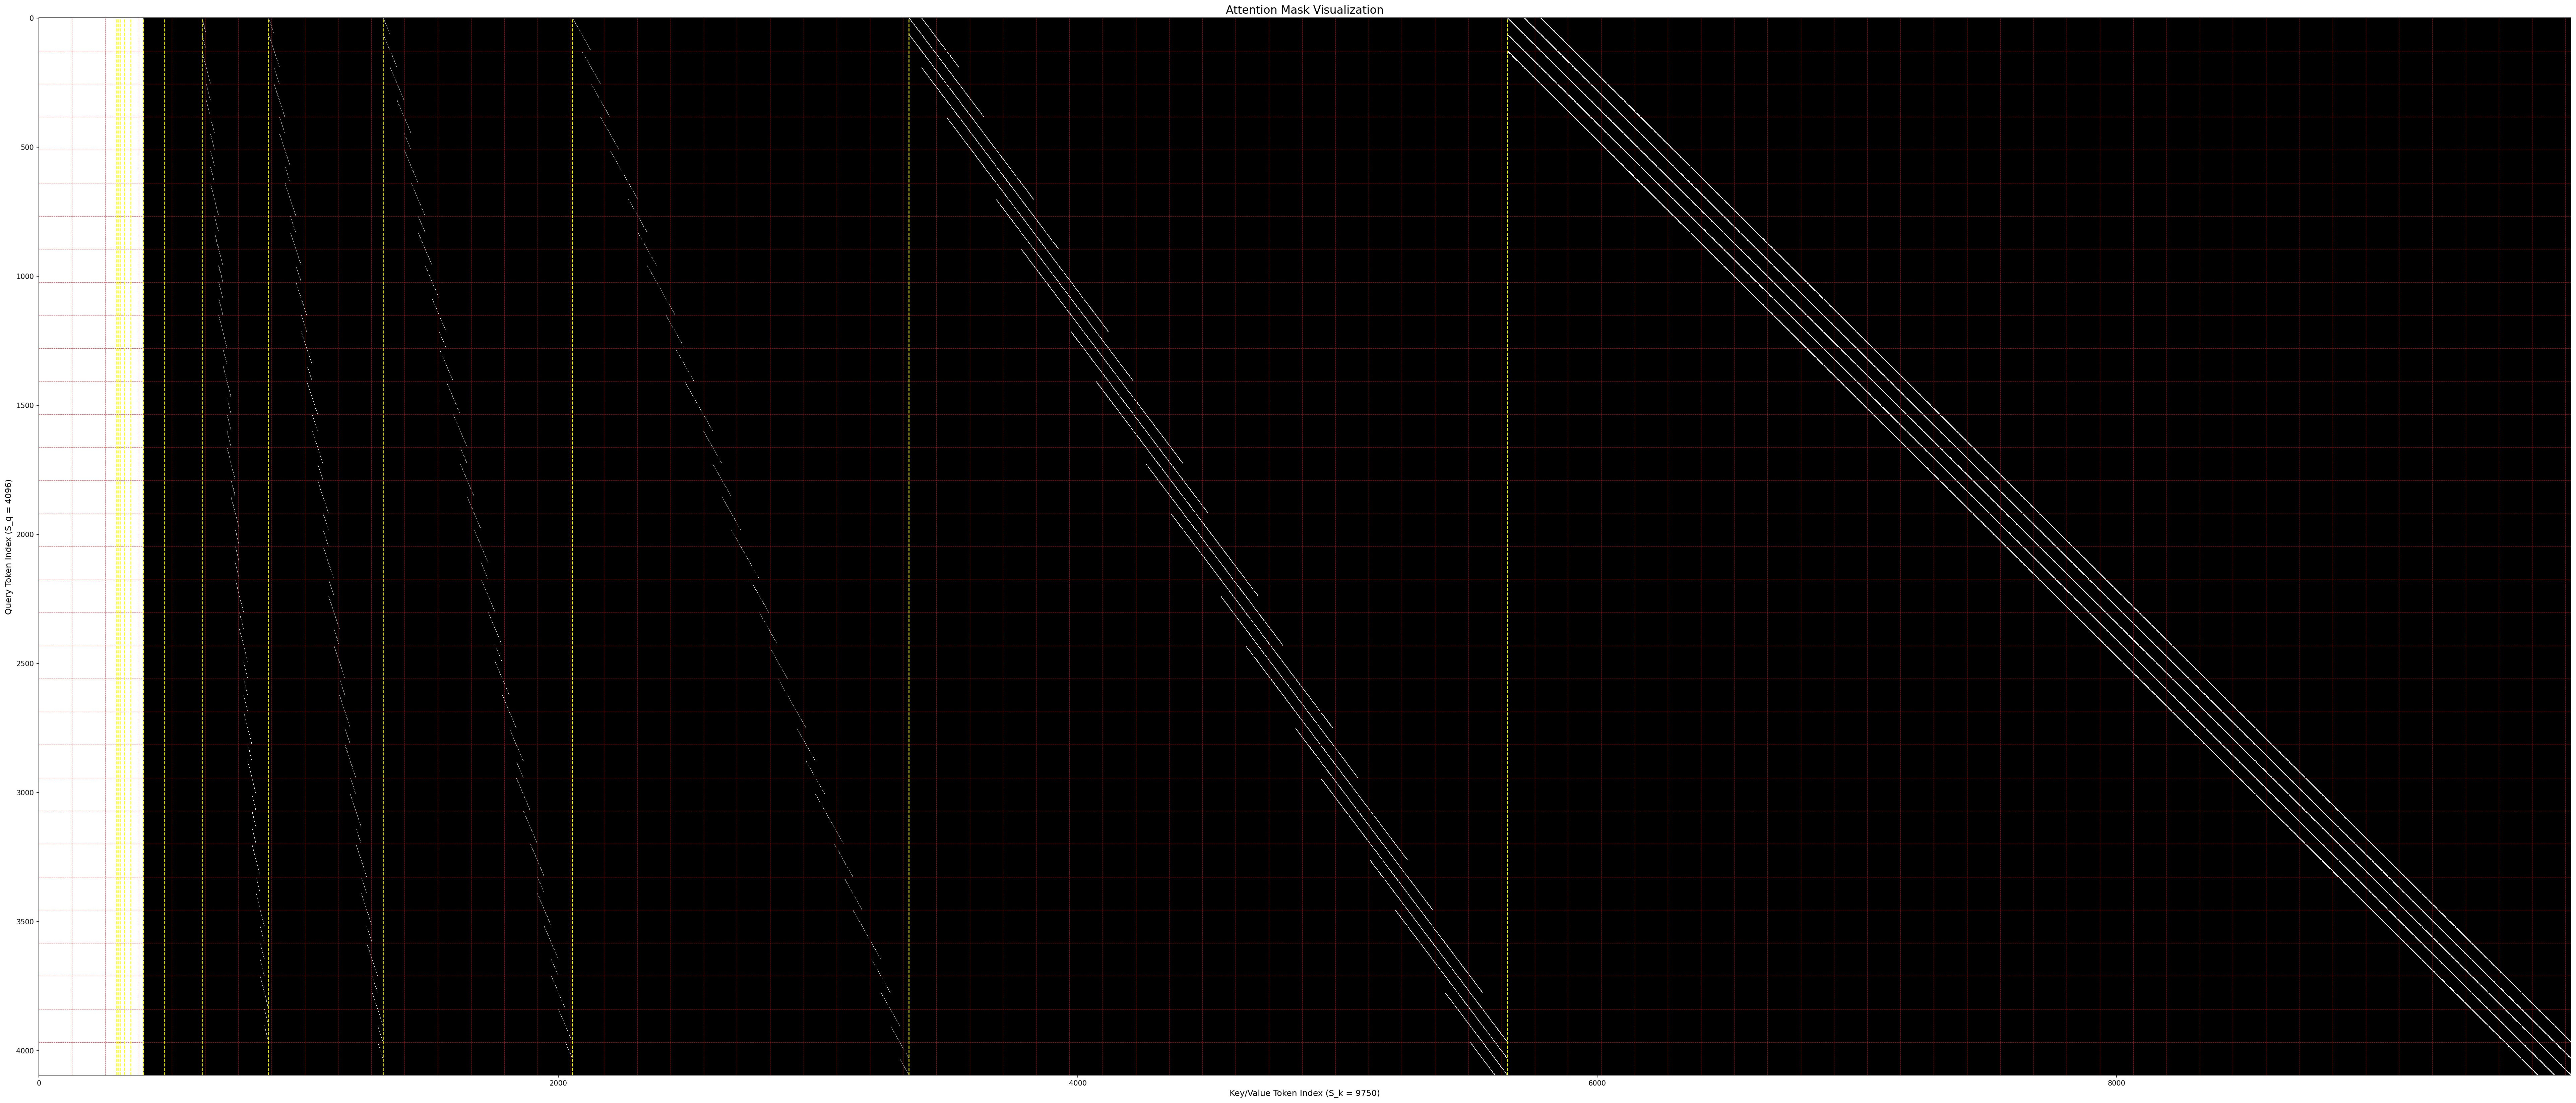

✅ Visualization with grid overlays saved to: /home/lizekun/workspace/Lvar/models/hart/attn_map_vis/hart_mask_q-13-ws-[-1, -1, -1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 3, 5]_sink-6_viz.png



In [11]:
visualize_mask(
    hart_mask_mod, scale_schedule, q_scale_idx, 
    filename=f"hart_mask_q-{q_scale_idx}-ws-{kernel_schedule[:q_scale_idx+1]}_sink-{attn_sink_scale}_viz.png"
)

In [12]:
# --- block-aligned hybrid mask ---
block_aligned_mask_mod = create_cross_scale_block_attn_mask(
    scale_schedule=scale_schedule,
    kernel_schedule=kernel_schedule,
    q_scale_idx=q_scale_idx,    # 当前Query是第几个尺度 (0-based, e.g., 12)
    attn_sink_scale=attn_sink_scale, # 注意力汇聚的尺度 (0-based, e.g., 5)
    device="cuda",
)

test_mask2(
    mask_mod=block_aligned_mask_mod, 
    B=batch, H=num_heads, D=head_dim,
    S_q=S_q, S_kv=S_kv, 
    sparse_block_size=block_size
)

Step 1: Generating internal fine-grained mask...
Step 2: Converting to 128x128 block-sparse format...
Step 3: Returning simplified block-lookup mask function.
Using sparse block size: 64


AUTOTUNE flex_attention_backward(2x24x4096x64, 2x24x9750x64, 2x24x9750x64, 2x24x4096, 2x24x4096, 2x24x4096x64, 2x24x4096x64, 2x24x9750x64, 1x1x64, 1x1x64x153, 1x1x153, 1x1x153x64, 1x1x64, 1x1x64x153, 1x1x153, 1x1x153x64, 32x77)
  triton_flex_attention_backward_25 14.1070 ms 100.0% BLOCKS_ARE_CONTIGUOUS=False, BLOCK_M1=64, BLOCK_M2=64, BLOCK_N1=64, BLOCK_N2=64, FLOAT32_PRECISION="'tf32'", GQA_SHARED_HEADS=1, HAS_FULL_BLOCKS=True, IS_DIVISIBLE=False, OUTPUT_LOGSUMEXP=True, PRESCALE_QK=False, QK_HEAD_DIM=64, QK_HEAD_DIM_ROUNDED=64, ROWS_GUARANTEED_SAFE=False, SAFE_HEAD_DIM=True, SM_SCALE=0.125, SPARSE_KV_BLOCK_SIZE=64, SPARSE_Q_BLOCK_SIZE=64, V_HEAD_DIM=64, V_HEAD_DIM_ROUNDED=64, WRITE_DQ=True, num_stages=3, num_warps=4
  triton_flex_attention_backward_24 14.1883 ms 99.4% BLOCKS_ARE_CONTIGUOUS=False, BLOCK_M1=64, BLOCK_M2=64, BLOCK_N1=64, BLOCK_N2=64, FLOAT32_PRECISION="'tf32'", GQA_SHARED_HEADS=1, HAS_FULL_BLOCKS=True, IS_DIVISIBLE=False, OUTPUT_LOGSUMEXP=True, PRESCALE_QK=False, QK_HEAD

Correctness check passed ✅

Results for final_block_mask_mod:
+---------------+----------------+-------------------+----------------+-------------------+
| Operation     |   FW Time (ms) |   FW FLOPS (TF/s) |   BW Time (ms) |   BW FLOPS (TF/s) |
+===============+================+===================+================+===================+
| FA2           |         1.638  |            299.6  |         4.9352 |            248.59 |
+---------------+----------------+-------------------+----------------+-------------------+
| F.sdpa + mask |         5.8598 |             16.84 |        14.2504 |             17.31 |
+---------------+----------------+-------------------+----------------+-------------------+
| flexattention |         0.405  |            243.56 |         1.3839 |            178.2  |
+---------------+----------------+-------------------+----------------+-------------------+

Block Mask:
BlockMask(shape=(1, 1, 4096, 9750), sparsity=79.90%, 
(0, 0)
██░░░░  ░░  ░░        ░░            

Mask generated. Now creating and saving visualization...


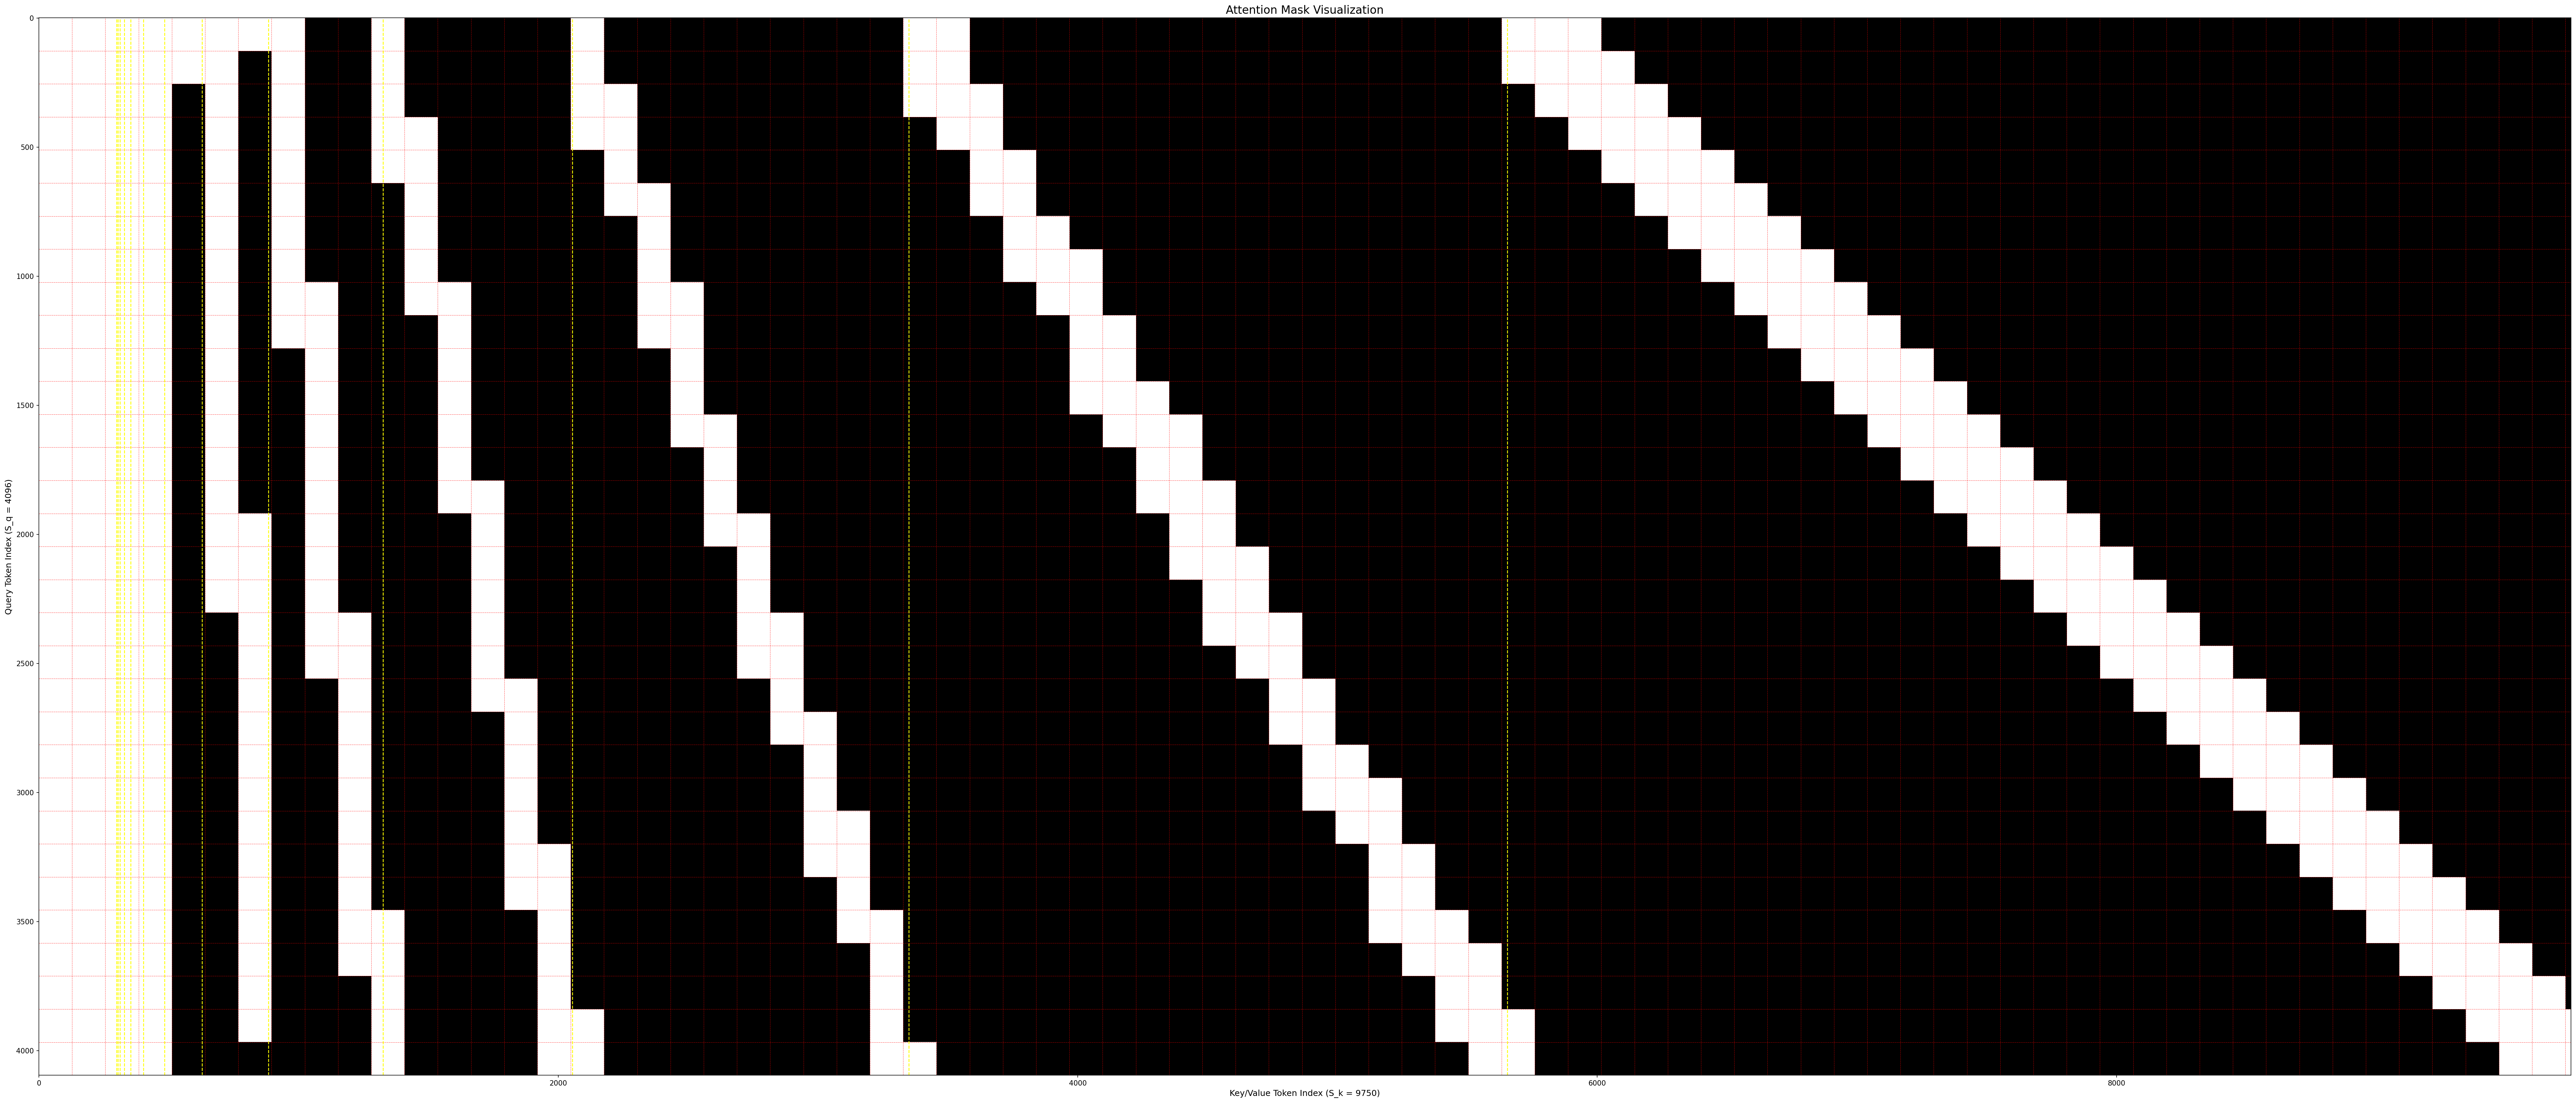

✅ Visualization with grid overlays saved to: /home/lizekun/workspace/Lvar/models/hart/attn_map_vis/hart_block-64_mask_q-13-ws-[-1, -1, -1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 3, 5]_sink-6_viz.png



In [13]:
visualize_mask(
    block_aligned_mask_mod, scale_schedule, q_scale_idx, 
    filename=f"hart_block-{block_size}_mask_q-{q_scale_idx}-ws-{kernel_schedule[:q_scale_idx+1]}_sink-{attn_sink_scale}_viz.png"
)

In [14]:
Results for final_block_mask_mod:
+---------------+----------------+-------------------+----------------+-------------------+
| Operation     |   FW Time (ms) |   FW FLOPS (TF/s) |   BW Time (ms) |   BW FLOPS (TF/s) |
+===============+================+===================+================+===================+
| FA2           |         1.6334 |            300.44 |         4.931  |            248.8  |
+---------------+----------------+-------------------+----------------+-------------------+
| F.sdpa + mask |         5.8161 |             17    |        14.2492 |             17.34 |
+---------------+----------------+-------------------+----------------+-------------------+
| flexattention |         0.3798 |            260.27 |         1.3722 |            180.09 |
+---------------+----------------+-------------------+----------------+-------------------+

SyntaxError: invalid syntax (1449324826.py, line 1)